# Outlier Treatment

## Month 5 | Day 11

### Objective

Apply IQR-based capping to flagged outlier columns and compare the dataset before and after treatment.

### Topics

- Outliers
- IQR
- Q1 and Q3
- Lower and upper bounds
- IQR-based capping
- Winsorization
- Before vs after comparison

### Dataset

HR Analytics Dataset

In [82]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [83]:
df = pd.read_csv("../data/raw/HR_Analytics.csv")

df.head()

,EmpID,Age,AgeGroup,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,RM297,18,18-25,Yes,Travel_Rarely,230,Research & Development,3,3,Life Sciences,...,3,80,0,0,2,3,0,0,0,0.0
1,RM302,18,18-25,No,Travel_Rarely,812,Sales,10,3,Medical,...,1,80,0,0,2,3,0,0,0,0.0
2,RM458,18,18-25,Yes,Travel_Frequently,1306,Sales,5,3,Marketing,...,4,80,0,0,3,3,0,0,0,0.0
3,RM728,18,18-25,No,Non-Travel,287,Research & Development,5,2,Life Sciences,...,4,80,0,0,2,3,0,0,0,0.0
4,RM829,18,18-25,Yes,Non-Travel,247,Research & Development,8,1,Medical,...,4,80,0,0,0,3,0,0,0,0.0


In [84]:
df['MonthlyIncome']

0        1420
1        1200
2        1878
3        1051
4        1904
        ...  
1475    19566
1476    10266
1477     5405
1478     5220
1479    10883
Name: MonthlyIncome, Length: 1480, dtype: int64

In [85]:
df['MonthlyIncome'].describe()

count     1480.000000
mean      6504.985811
std       4700.261400
min       1009.000000
25%       2922.250000
50%       4933.000000
75%       8383.750000
max      19999.000000
Name: MonthlyIncome, dtype: float64

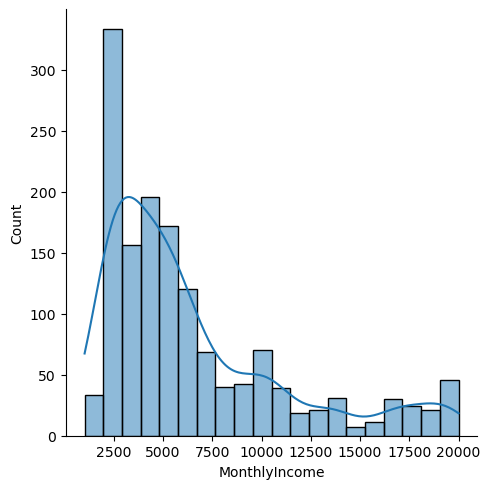

In [86]:
sns.displot(df['MonthlyIncome'], kde=True)

<Axes: ylabel='MonthlyIncome'>

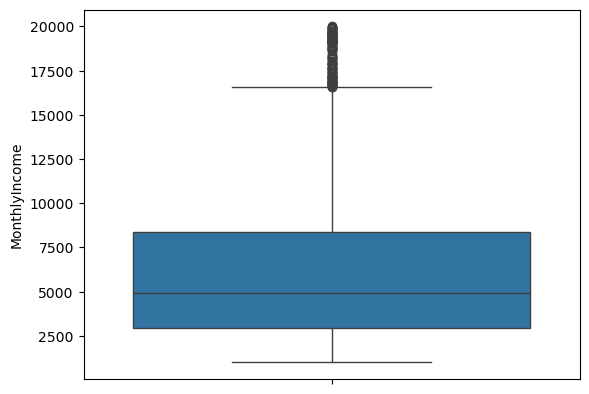

In [87]:
sns.boxplot(df['MonthlyIncome'])

In [88]:
q1 = df['MonthlyIncome'].quantile(0.25)
q3 = df['MonthlyIncome'].quantile(0.75)

In [89]:
q1

np.float64(2922.25)

In [90]:
q3

np.float64(8383.75)

In [91]:
iqr = q3 - q1
iqr

np.float64(5461.5)

In [92]:
lower_bound = q1 - 1.5 * iqr
lower_bound

np.float64(-5270.0)

In [93]:
upper_bound = q3 + 1.5 * iqr
upper_bound

np.float64(16576.0)

In [94]:
df_trimmed = df[
    (df["MonthlyIncome"] >= lower_bound) &
    (df["MonthlyIncome"] <= upper_bound)
]

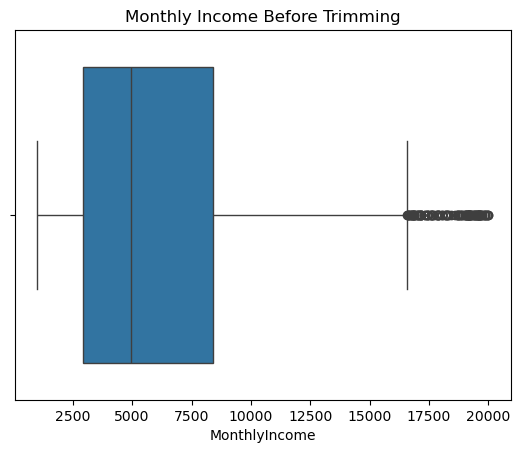

In [95]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x=df["MonthlyIncome"])
plt.title("Monthly Income Before Trimming")
plt.show()

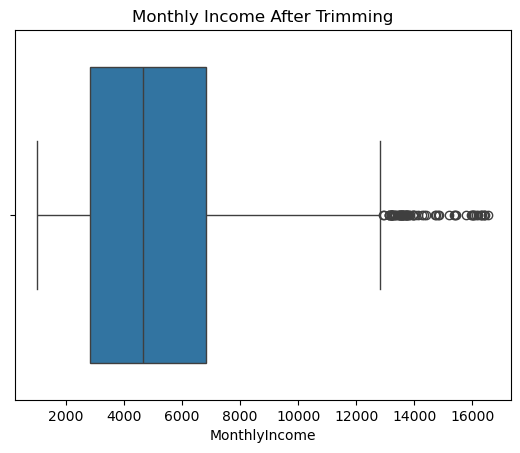

In [96]:
sns.boxplot(x=df_trimmed["MonthlyIncome"])
plt.title("Monthly Income After Trimming")
plt.show()

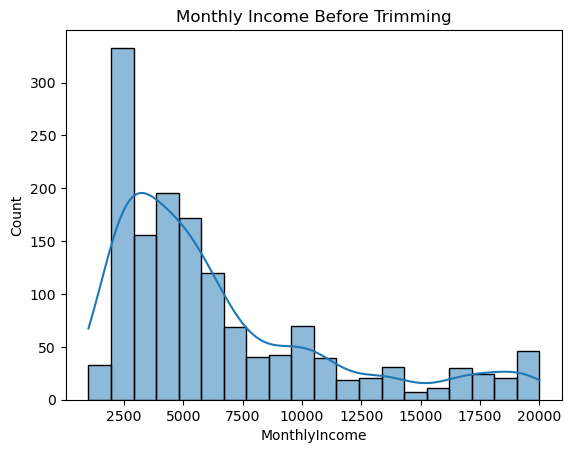

In [97]:
sns.histplot(df["MonthlyIncome"], kde=True)
plt.title("Monthly Income Before Trimming")
plt.show()

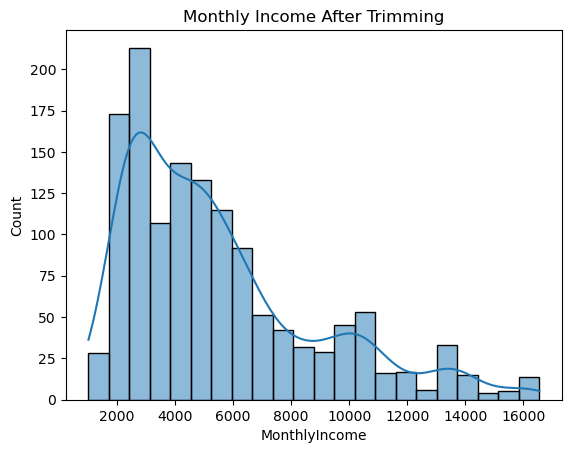

In [98]:
sns.histplot(df_trimmed["MonthlyIncome"], kde=True)
plt.title("Monthly Income After Trimming")
plt.show()

In [99]:
df['MonthlyIncome'].describe()

count     1480.000000
mean      6504.985811
std       4700.261400
min       1009.000000
25%       2922.250000
50%       4933.000000
75%       8383.750000
max      19999.000000
Name: MonthlyIncome, dtype: float64

In [100]:
lower_limit = df["MonthlyIncome"].quantile(0.10)
upper_limit = df["MonthlyIncome"].quantile(0.90)

df["MonthlyIncome_Capped"] = np.where(
    df["MonthlyIncome"] >= upper_limit,
    upper_limit,
    np.where(
        df["MonthlyIncome"] <= lower_limit,
        lower_limit,
        df["MonthlyIncome"]
    )
)

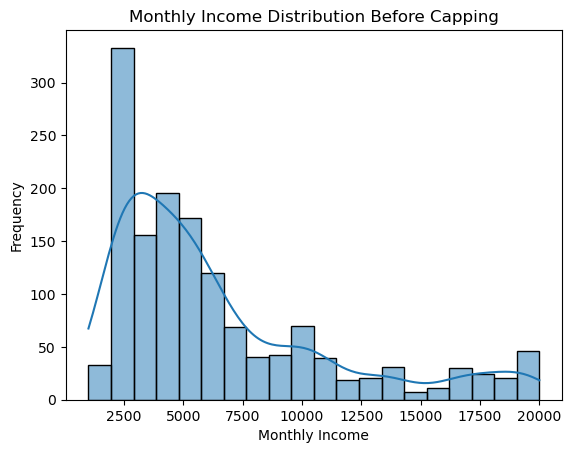

In [101]:
sns.histplot(df["MonthlyIncome"], kde=True)

plt.title("Monthly Income Distribution Before Capping")
plt.xlabel("Monthly Income")
plt.ylabel("Frequency")
plt.show()

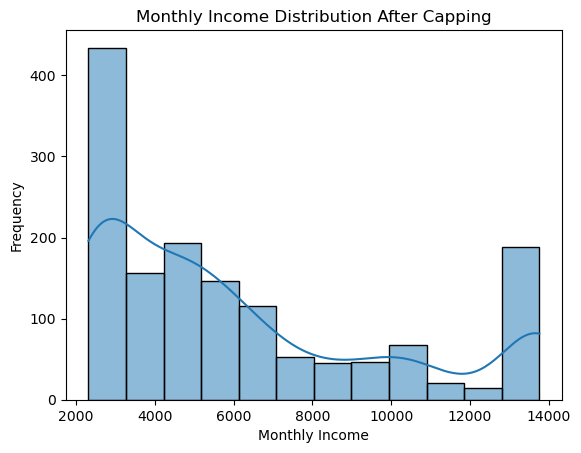

In [102]:
sns.histplot(df["MonthlyIncome_Capped"], kde=True)

plt.title("Monthly Income Distribution After Capping")
plt.xlabel("Monthly Income")
plt.ylabel("Frequency")
plt.show()

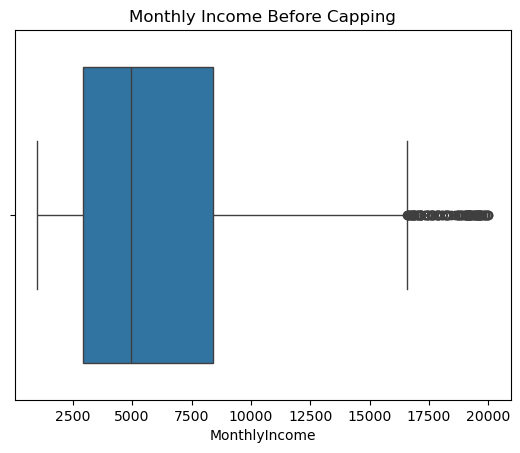

In [104]:
sns.boxplot(x=df["MonthlyIncome"])

plt.title("Monthly Income Before Capping")
plt.show()

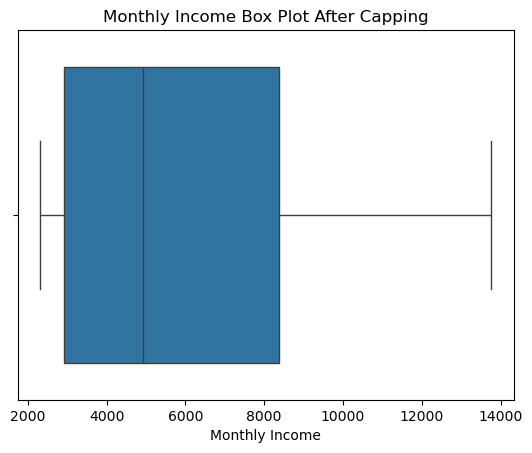

In [103]:
sns.boxplot(x=df["MonthlyIncome_Capped"])

plt.title("Monthly Income Box Plot After Capping")
plt.xlabel("Monthly Income")
plt.show()